# Exit Rules: Stop-Loss, Take-Profit & Trailing Stop

quaver's backtest engine supports **automatic exit rules** that check intra-bar
high/low prices every bar *before* `strategy.compute()` runs.

## Two configuration paths

1. **Global rules** (`ExitRules`) -- percentage-based, apply to all trades
2. **Per-trade overrides** -- absolute price levels via `SignalOutput.metadata`

## Exit priority (pessimistic)

When multiple exits trigger on the same bar: **Stop-Loss > Trailing Stop > Take-Profit**

Fills occur at the **trigger price level**, not at bar close.

Every exit is tagged with an `ExitReason` enum:
- `SIGNAL` -- closed by strategy signal
- `STOP_LOSS` -- stop-loss triggered
- `TAKE_PROFIT` -- take-profit triggered
- `TRAILING_STOP` -- trailing stop triggered
- `END_OF_DATA` -- force-closed at end of data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import Any

from quaver.backtest.engine import BacktestEngine
from quaver.backtest.portfolio import ExitRules, Portfolio
from quaver.strategies.base import BaseStrategy, SignalOutput
from quaver.types import ExitReason, SignalDirection

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Helpers
BASE_TS = datetime(2024, 1, 1)


def ts(i):
    return BASE_TS + timedelta(days=i)


def make_candles(bars):
    """Create candles from (open, high, low, close) tuples."""
    rows = []
    for i, (o, h, lo, c) in enumerate(bars):
        rows.append({"ts": ts(i), "open": o, "high": h, "low": lo, "close": c, "volume": 100})
    return pd.DataFrame(rows)


class BuyOnceStrategy(BaseStrategy):
    """Emits BUY on first compute call, then HOLD."""

    def __init__(self, parameters=None, *, metadata=None):
        super().__init__(parameters or {})
        self._metadata = metadata
        self._bought = False

    def validate_parameters(self):
        pass

    def get_required_candle_count(self):
        return 1

    def compute(self, candles, as_of):
        if not self._bought:
            self._bought = True
            return SignalOutput(
                direction=SignalDirection.BUY,
                confidence=0.9,
                metadata=self._metadata,
            )
        return None


def show_trade(result):
    """Print trade details."""
    for t in result.trades:
        print(f"  Entry: {t.entry_price:.2f} at {t.entry_ts.date()}")
        print(f"  Exit:  {t.exit_price:.2f} at {t.exit_ts.date()}")
        print(f"  P&L:   {t.pnl:+.2f}")
        print(f"  Exit Reason: {t.exit_reason}")
        print()

## 1. Stop-Loss

A stop-loss exits the position when price moves adversely by a set percentage.

- **Long**: triggers when `low <= entry * (1 - stop_loss_pct)`
- **Short**: triggers when `high >= entry * (1 + stop_loss_pct)`

Stop-Loss Example:
  Entry: 100.00 at 2024-01-02
  Exit:  95.00 at 2024-01-03
  P&L:   -50.00
  Exit Reason: ExitReason.STOP_LOSS



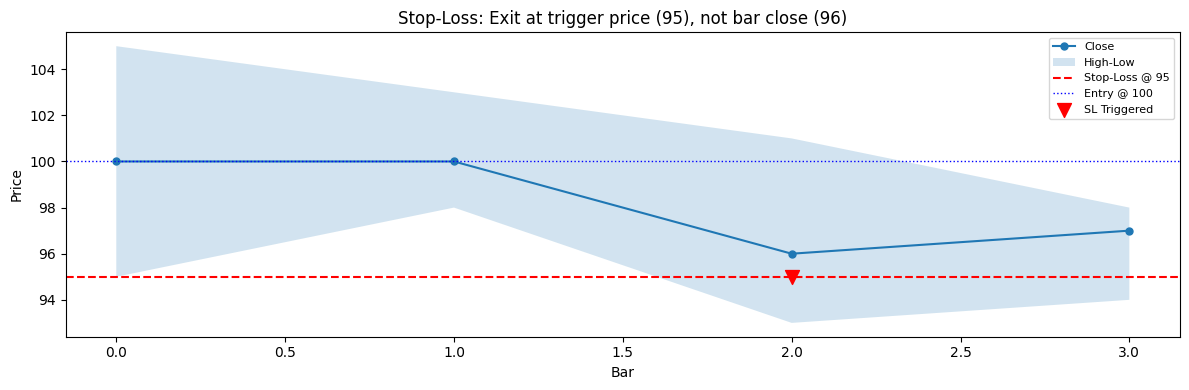

In [3]:
# Entry at 100, 5% SL = 95. Bar 2 has low=93 -> triggers at 95.
rules = ExitRules(stop_loss_pct=0.05)
portfolio = Portfolio(initial_capital=10_000, quantity_per_trade=10, exit_rules=rules)
engine = BacktestEngine(
    strategy=BuyOnceStrategy(),
    portfolio=portfolio,
    instrument_id="DEMO",
)

candles = make_candles([
    (100, 105, 95, 100),   # warmup
    (100, 103, 98, 100),   # BUY at 100
    (99, 101, 93, 96),     # low=93 breaches SL=95 -> exit at 95
    (96, 98, 94, 97),      # not reached
])

result = engine.run(candles)
print("Stop-Loss Example:")
show_trade(result)

# Visualise
fig, ax = plt.subplots()
ax.plot(range(len(candles)), candles["close"], "o-", label="Close", markersize=5)
ax.fill_between(range(len(candles)), candles["low"], candles["high"], alpha=0.2, label="High-Low")
ax.axhline(95, color="red", linestyle="--", linewidth=1.5, label="Stop-Loss @ 95")
ax.axhline(100, color="blue", linestyle=":", linewidth=1, label="Entry @ 100")
ax.scatter([2], [95], color="red", s=100, zorder=5, marker="v", label="SL Triggered")
ax.set_title("Stop-Loss: Exit at trigger price (95), not bar close (96)")
ax.legend(fontsize=8)
ax.set_xlabel("Bar")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

## 2. Take-Profit

A take-profit exits the position when price moves favorably by a set percentage.

- **Long**: triggers when `high >= entry * (1 + take_profit_pct)`
- **Short**: triggers when `low <= entry * (1 - take_profit_pct)`

Take-Profit Example:
  Entry: 100.00 at 2024-01-02
  Exit:  110.00 at 2024-01-03
  P&L:   +100.00
  Exit Reason: ExitReason.TAKE_PROFIT



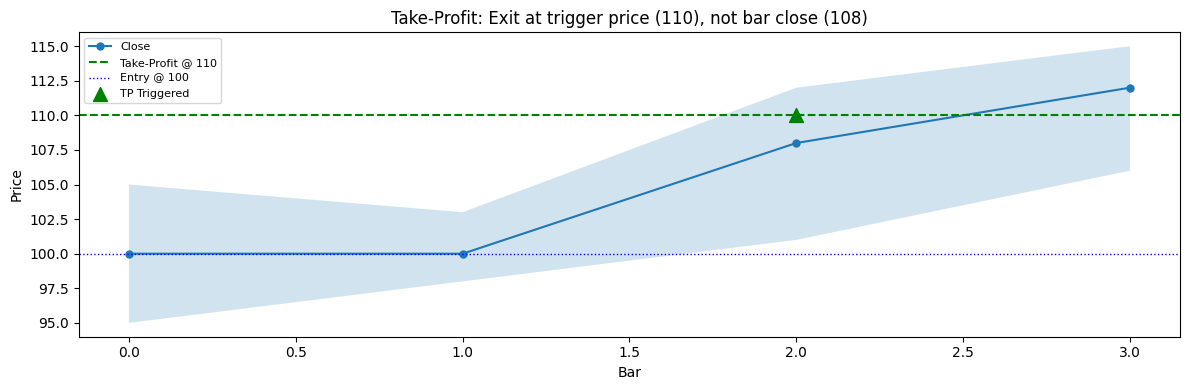

In [4]:
# Entry at 100, 10% TP = 110. Bar 2 has high=112 -> triggers at 110.
rules = ExitRules(take_profit_pct=0.10)
portfolio = Portfolio(initial_capital=10_000, quantity_per_trade=10, exit_rules=rules)
engine = BacktestEngine(
    strategy=BuyOnceStrategy(),
    portfolio=portfolio,
    instrument_id="DEMO",
)

candles = make_candles([
    (100, 105, 95, 100),   # warmup
    (100, 103, 98, 100),   # BUY at 100
    (102, 112, 101, 108),  # high=112 >= TP=110 -> exit at 110
    (108, 115, 106, 112),  # not reached
])

result = engine.run(candles)
print("Take-Profit Example:")
show_trade(result)

fig, ax = plt.subplots()
ax.plot(range(len(candles)), candles["close"], "o-", label="Close", markersize=5)
ax.fill_between(range(len(candles)), candles["low"], candles["high"], alpha=0.2)
ax.axhline(110, color="green", linestyle="--", linewidth=1.5, label="Take-Profit @ 110")
ax.axhline(100, color="blue", linestyle=":", linewidth=1, label="Entry @ 100")
ax.scatter([2], [110], color="green", s=100, zorder=5, marker="^", label="TP Triggered")
ax.set_title("Take-Profit: Exit at trigger price (110), not bar close (108)")
ax.legend(fontsize=8)
ax.set_xlabel("Bar")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

## 3. Trailing Stop

A trailing stop follows the price as it moves in your favor and triggers when
price retraces by a set percentage from the extreme.

- **Long**: tracks `highest high` since entry. Triggers when `low <= extreme * (1 - pct)`
- **Short**: tracks `lowest low` since entry. Triggers when `high >= extreme * (1 + pct)`

Trailing Stop Example:
  Entry: 100.00 at 2024-01-02
  Exit:  104.50 at 2024-01-03
  P&L:   +45.00
  Exit Reason: ExitReason.TRAILING_STOP



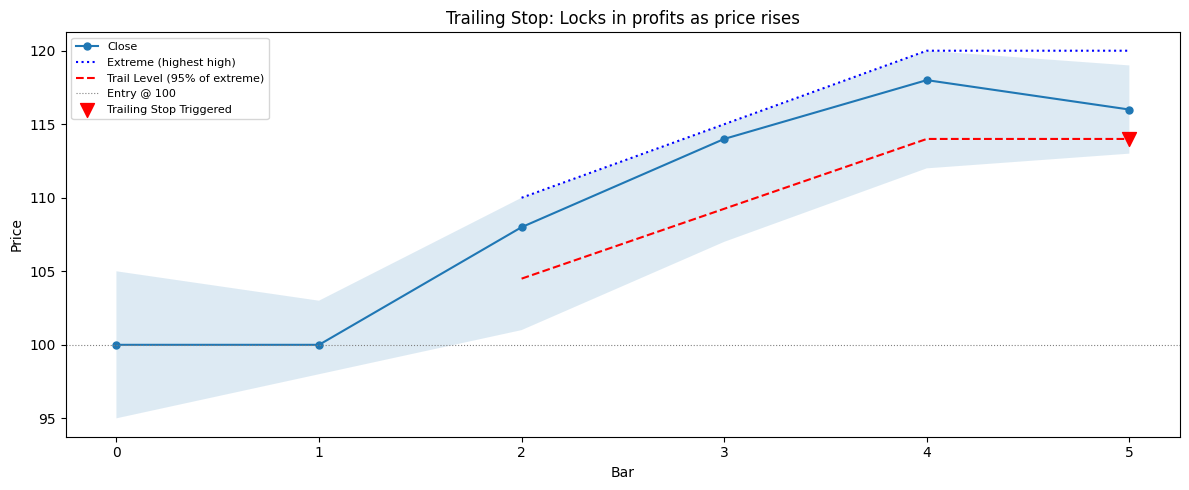

In [5]:
# Entry at 100, 5% trailing stop.
# Price rises to 120 (extreme), then drops.
# Trail level = 120 * 0.95 = 114. Bar with low=113 triggers.
rules = ExitRules(trailing_stop_pct=0.05)
portfolio = Portfolio(initial_capital=10_000, quantity_per_trade=10, exit_rules=rules)
engine = BacktestEngine(
    strategy=BuyOnceStrategy(),
    portfolio=portfolio,
    instrument_id="DEMO",
)

candles = make_candles([
    (100, 105, 95, 100),   # warmup
    (100, 103, 98, 100),   # BUY at 100, extreme=100
    (102, 110, 101, 108),  # extreme -> 110, trail=104.5
    (108, 115, 107, 114),  # extreme -> 115, trail=109.25
    (114, 120, 112, 118),  # extreme -> 120, trail=114
    (117, 119, 113, 116),  # trail=114 (extreme still 120), low=113 triggers!
])

result = engine.run(candles)
print("Trailing Stop Example:")
show_trade(result)

# Build trail level series for plotting
highs = candles["high"].values
extreme_series = [np.nan, np.nan]  # warmup + entry bar
trail_series = [np.nan, np.nan]
extreme = 100.0  # entry price
for i in range(2, len(candles)):
    extreme = max(extreme, highs[i])
    extreme_series.append(extreme)
    trail_series.append(extreme * 0.95)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(candles)), candles["close"], "o-", label="Close", markersize=5)
ax.fill_between(range(len(candles)), candles["low"], candles["high"], alpha=0.15)
ax.plot(range(len(candles)), extreme_series, color="blue", linestyle=":", label="Extreme (highest high)")
ax.plot(range(len(candles)), trail_series, color="red", linestyle="--", label="Trail Level (95% of extreme)")
ax.axhline(100, color="grey", linestyle=":", linewidth=0.8, label="Entry @ 100")
ax.scatter([5], [120 * 0.95], color="red", s=100, zorder=5, marker="v", label="Trailing Stop Triggered")
ax.set_title("Trailing Stop: Locks in profits as price rises")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlabel("Bar")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

## 4. Pessimistic Priority: SL Wins Over TP on Same Bar

When both stop-loss and take-profit trigger on the same bar,
quaver takes the **pessimistic** outcome (stop-loss wins).

In [6]:
# Entry at 100. SL=95, TP=110.
# Bar has low=94 AND high=112 -> both trigger. SL wins.
rules = ExitRules(stop_loss_pct=0.05, take_profit_pct=0.10)
portfolio = Portfolio(initial_capital=10_000, quantity_per_trade=10, exit_rules=rules)
engine = BacktestEngine(
    strategy=BuyOnceStrategy(),
    portfolio=portfolio,
    instrument_id="DEMO",
)

candles = make_candles([
    (100, 105, 95, 100),
    (100, 103, 98, 100),   # BUY at 100
    (100, 112, 94, 105),   # Both SL=95 and TP=110 trigger
])

result = engine.run(candles)
trade = result.trades[0]
print(f"Exit Reason: {trade.exit_reason} (pessimistic -- SL wins)")
print(f"Exit Price: {trade.exit_price} (SL price, not TP price)")
print(f"P&L: {trade.pnl:+.2f}")

Exit Reason: ExitReason.STOP_LOSS (pessimistic -- SL wins)
Exit Price: 95.0 (SL price, not TP price)
P&L: -50.00


## 5. Per-Trade Metadata Overrides

Strategies can set **absolute price levels** in `SignalOutput.metadata` to override global rules:

- `metadata["stop_loss"]` -- absolute SL price (overrides `stop_loss_pct`)
- `metadata["take_profit"]` -- absolute TP price (overrides `take_profit_pct`)
- `metadata["trailing_stop_pct"]` -- per-trade trailing % (overrides `trailing_stop_pct`)

In [7]:
# Global SL is 5% (=95), but per-trade metadata overrides it to 92.
rules = ExitRules(stop_loss_pct=0.05)
portfolio = Portfolio(initial_capital=10_000, quantity_per_trade=10, exit_rules=rules)
engine = BacktestEngine(
    strategy=BuyOnceStrategy(metadata={"stop_loss": 92.0}),
    portfolio=portfolio,
    instrument_id="DEMO",
)

candles = make_candles([
    (100, 105, 95, 100),
    (100, 103, 98, 100),   # BUY at 100
    (99, 101, 93, 97),     # low=93, global SL=95 WOULD trigger, but override SL=92 does NOT
    (97, 99, 91, 94),      # low=91, override SL=92 triggers
])

result = engine.run(candles)
trade = result.trades[0]
print(f"Per-trade SL override: 92.0 (global would be 95.0)")
print(f"Exit Price: {trade.exit_price} (at override SL=92)")
print(f"Exit Reason: {trade.exit_reason}")
print(f"Exit at bar index 3, not bar 2 (where global SL would have triggered)")

Per-trade SL override: 92.0 (global would be 95.0)
Exit Price: 92.0 (at override SL=92)
Exit Reason: ExitReason.STOP_LOSS
Exit at bar index 3, not bar 2 (where global SL would have triggered)


## 6. Combining All Three Exit Rules

A realistic configuration uses SL + TP + trailing stop together.
Let's run a longer scenario to see how they interact.

In [ ]:
class RepeatBuyer(BaseStrategy):
    """Buys whenever flat."""

    def __init__(self, parameters=None):
        super().__init__(parameters or {})

    def validate_parameters(self):
        pass

    def get_required_candle_count(self):
        return 1

    def compute(self, candles, as_of):
        # This will be called only when no exit trigger fires
        return SignalOutput(direction=SignalDirection.BUY, confidence=0.8)


np.random.seed(99)
n_bars = 100
base = 100 + np.cumsum(np.random.randn(n_bars) * 1.5)
h = base + np.abs(np.random.randn(n_bars) * 2)
lo = base - np.abs(np.random.randn(n_bars) * 2)
bars = [(base[i], h[i], lo[i], base[i]) for i in range(n_bars)]
candles = make_candles(bars)

rules = ExitRules(stop_loss_pct=0.03, take_profit_pct=0.05, trailing_stop_pct=0.02)
portfolio = Portfolio(initial_capital=10_000, quantity_per_trade=10, exit_rules=rules)
engine = BacktestEngine(
    strategy=RepeatBuyer(),
    portfolio=portfolio,
    instrument_id="DEMO",
)
result = engine.run(candles)

print(f"Total trades: {result.total_trades}")
print(f"Total return: {result.total_return * 100:.2f}%")
print()

# Count by exit reason
from collections import Counter
reason_counts = Counter(t.exit_reason for t in result.trades)
for reason, count in sorted(reason_counts.items(), key=lambda x: -x[1]):
    print(f"  {reason}: {count} trades")

In [ ]:
# Visualise trades colored by exit reason
color_map = {
    ExitReason.STOP_LOSS: "red",
    ExitReason.TAKE_PROFIT: "green",
    ExitReason.TRAILING_STOP: "orange",
    ExitReason.END_OF_DATA: "grey",
    ExitReason.SIGNAL: "blue",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(range(len(candles)), candles["close"], linewidth=0.8, alpha=0.5)
for t in result.trades:
    entry_idx = (t.entry_ts - BASE_TS).days
    exit_idx = (t.exit_ts - BASE_TS).days
    color = color_map.get(t.exit_reason, "black")
    axes[0].scatter(entry_idx, t.entry_price, color="blue", s=30, zorder=3, marker="^")
    axes[0].scatter(exit_idx, t.exit_price, color=color, s=30, zorder=3, marker="v")
    axes[0].plot([entry_idx, exit_idx], [t.entry_price, t.exit_price],
                 color=color, alpha=0.3, linewidth=1)

# Legend
for reason, color in color_map.items():
    if reason in reason_counts:
        axes[0].scatter([], [], color=color, marker="v", label=f"{reason.value} ({reason_counts[reason]})")
axes[0].scatter([], [], color="blue", marker="^", label="Entry")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_title("Trades with Exit Rules (SL=3%, TP=5%, Trail=2%)")
axes[0].set_ylabel("Price")

# Cumulative P&L
cpnl = result.cumulative_pnl
axes[1].plot(range(len(cpnl)), cpnl, linewidth=1.5)
axes[1].axhline(0, color="grey", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Cumulative P&L ($)")
axes[1].set_xlabel("Trade #")
axes[1].set_title("Equity Curve")

plt.tight_layout()
plt.show()

## Summary

| Feature | Config | Trigger |
|---------|--------|---------|
| **Stop-Loss** | `ExitRules(stop_loss_pct=0.05)` | Long: `low <= entry * 0.95` |
| **Take-Profit** | `ExitRules(take_profit_pct=0.10)` | Long: `high >= entry * 1.10` |
| **Trailing Stop** | `ExitRules(trailing_stop_pct=0.03)` | Long: `low <= highest_high * 0.97` |
| **Per-trade override** | `metadata={"stop_loss": 92.0}` | Absolute price, overrides global |

All exits:
- Run **before** `strategy.compute()` each bar
- Fill at the **trigger price**, not bar close
- Are tagged with `ExitReason` in `TradeRecord`
- Apply commission & slippage normally
- Are fully backward-compatible (no `ExitRules` = no triggers)